In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import HuberRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

In [2]:
#Model evaluation function
def evaluate_models(X_train, X_test, y_train, y_test):

    models = {
        "OLS": LinearRegression(),

        "Ridge": Ridge(alpha=1.0),

        "Huber": HuberRegressor(
            max_iter=1000
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ),

        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    }

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        rmse = np.sqrt(
            mean_squared_error(y_test, predictions)
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    return pd.DataFrame(results)

In [3]:
#Generate baseline data
def generate_baseline_data(n=1000, seed=None):

    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.normal(0, 1, n)
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)

    error = np.random.normal(0, 1, n)

    Y = (
        3
        + 2 * X1
        + 1.5 * X2
        - X3
        + error
    )

    return pd.DataFrame({
        "X1": X1,
        "X2": X2,
        "X3": X3,
        "Y": Y
    })

In [4]:
#Run one experiment
data = generate_baseline_data(
    n=1000,
    seed=42
)

X = data[["X1", "X2", "X3"]]
y = data["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

baseline_results = evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test
)

baseline_results

,Model,RMSE,MAE,R2
0,OLS,1.036938,0.827121,0.876029
1,Ridge,1.037339,0.827542,0.875933
2,Huber,1.037429,0.828090,0.875911
3,Random Forest,1.228379,0.956959,0.826028
4,XGBoost,1.132448,0.897738,0.852140


In [5]:
#Repeat 30 times
def run_baseline_experiment(seed):

    data = generate_baseline_data(
        n=1000,
        seed=seed
    )

    X = data[["X1", "X2", "X3"]]
    y = data["Y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed
    )

    results = evaluate_models(
        X_train,
        X_test,
        y_train,
        y_test
    )

    results["Seed"] = seed

    return results

In [6]:
all_results = []

for seed in range(30):

    results = run_baseline_experiment(seed)

    all_results.append(results)

repeated_results = pd.concat(
    all_results,
    ignore_index=True
)

repeated_results.head()

,Model,RMSE,MAE,R2,Seed
0,OLS,1.072063,0.852017,0.834188,0
1,Ridge,1.071612,0.851828,0.834327,0
2,Huber,1.073106,0.851596,0.833865,0
3,Random Forest,1.200572,0.942151,0.792053,0
4,XGBoost,1.108609,0.888609,0.822690,0


In [7]:
#Mean and SD
mean_results = (
    repeated_results
    .groupby("Model")[["RMSE", "MAE", "R2"]]
    .mean()
    .reset_index()
)

std_results = (
    repeated_results
    .groupby("Model")[["RMSE", "MAE", "R2"]]
    .std()
    .reset_index()
)

summary_results = mean_results.copy()

summary_results["RMSE_SD"] = std_results["RMSE"]
summary_results["MAE_SD"] = std_results["MAE"]
summary_results["R2_SD"] = std_results["R2"]

summary_results

,Model,RMSE,MAE,R2,RMSE_SD,MAE_SD,R2_SD
0,Huber,1.005917,0.802398,0.875620,0.051028,0.049117,0.016515
1,OLS,1.005350,0.801839,0.875764,0.050600,0.048655,0.016435
2,Random Forest,1.157749,0.921563,0.835381,0.063467,0.053696,0.020727
3,Ridge,1.005413,0.801921,0.875753,0.050542,0.048610,0.016392
4,XGBoost,1.091297,0.873349,0.853715,0.058348,0.052187,0.018650


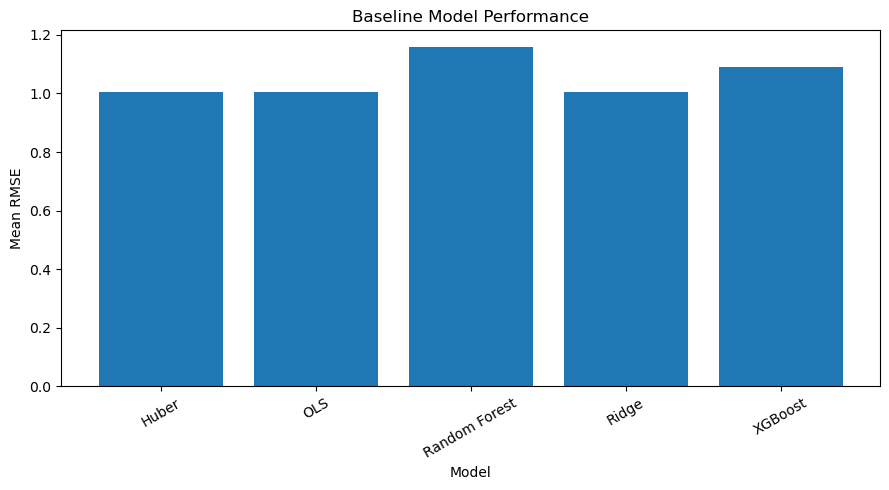

<class 'FileNotFoundError'>: [Errno 44] No such file or directory: '../results/figures/baseline_model_comparison.png'

In [12]:
#Plot
plt.figure(figsize=(9, 5))

plt.bar(
    summary_results["Model"],
    summary_results["RMSE"]
)

plt.ylabel("Mean RMSE")
plt.xlabel("Model")
plt.title("Baseline Model Performance")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../results/figures/baseline_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [16]:
from pathlib import Path

# Create project output directories
tables_dir = Path("../results/tables")
figures_dir = Path("../results/figures")

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

In [17]:
#save csv file
summary_results.to_csv(
    tables_dir / "baseline_results.csv",
    index=False
)

In [22]:
#save plot
plt.savefig(
    figures_dir / "baseline_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>